# Validación de RSF-PHATE con Datos Sintéticos

**TFG — Diego Suárez | Tutor: Luciano**

---

Este notebook valida que RSF-PHATE **recupera los clusters conocidos** cuando se aplica
sobre datos sintéticos con verdad de tierra (`CLUSTER_REAL`).

Si el método funciona bien, los clusters que asigne deben coincidir en gran medida con
los que nosotros diseñamos al generar los datos. Medimos esto con el
**Adjusted Rand Index (ARI)**: 0 = asignación aleatoria, 1 = coincidencia perfecta.

**Clusters diseñados:**

| Cluster | Perfil | Churn | Distribución survival |
|---------|--------|-------|----------------------|
| 0 | Nuevos en riesgo | ~19% | Weibull shape=0.75 (riesgo decreciente) |
| 1 | Fieles maduros   |  ~6% | Weibull shape=2.50 (riesgo creciente)  |
| 2 | Riesgo medio     | ~10% | Weibull shape=1.20 (riesgo moderado)   |


In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from sklearn.metrics import adjusted_rand_score, confusion_matrix, ConfusionMatrixDisplay
from sksurv.nonparametric import kaplan_meier_estimator

warnings.filterwarnings('ignore')

sys.path.insert(0, os.path.abspath(os.path.join('..', 'examples')))
from churn_preprocessing import preprocesar_supervivencia

from rsfphate import RSFPhate
from rsfphate.spectral import yu_shi

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
PALETTE = cm.get_cmap('tab10', 3)

DATA_PATH = os.path.abspath(
    os.path.join('..', '..', 'ClusterScripts', 'datos_sinteticos_electricidad.csv')
)
print('Imports OK')


Imports OK


## 1. Carga y submuestreo estratificado por CLUSTER_REAL

Submuestra estratificada por `CLUSTER_REAL` (no por `TARGET`) para garantizar que
los tres clusters están representados en la muestra.


In [2]:
df_raw = pd.read_csv(DATA_PATH, encoding='utf-8')
print(f'Dataset sintético: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas')
print(f'Churn rate global: {df_raw.TARGET.mean():.2%}')
print()

# Submuestreo estratificado por CLUSTER_REAL
N_SAMPLES = 1200
frac = N_SAMPLES / len(df_raw)
df_sample = (
    df_raw.groupby('CLUSTER_REAL', group_keys=False)
    .apply(lambda g: g.sample(frac=frac, random_state=RANDOM_STATE))
    .reset_index(drop=True)
)

print(f'Muestra: {len(df_sample)} filas')
print(df_sample.groupby('CLUSTER_REAL').agg(
    n=('TARGET','count'),
    churn=('TARGET','mean'),
).assign(churn=lambda x: (x.churn*100).round(1).astype(str)+'%').to_string())


Dataset sintético: 500,000 filas x 44 columnas
Churn rate global: 10.36%

Muestra: 1200 filas
                n  churn
CLUSTER_REAL            
0             301  18.6%
1             600   6.2%
2             299   9.4%


In [3]:
# Guardamos CLUSTER_REAL ANTES de que el preprocesado lo trate como feature
# (preprocesar_supervivencia lo ignoraria pero lo mantendriamos como columna extra)
cluster_real = df_sample['CLUSTER_REAL'].reset_index(drop=True)

# Eliminamos CLUSTER_REAL y CLIENTE_ID del dataframe antes de preprocesar
# para que no entren como features del modelo
df_clean = df_sample.drop(columns=['CLUSTER_REAL', 'CLIENTE_ID'], errors='ignore')

X, time, event = preprocesar_supervivencia(df_clean)

# Re-alineamos cluster_real con el indice que queda tras el dropna
cluster_real = cluster_real.loc[X.index].reset_index(drop=True)
X = X.reset_index(drop=True)
time = time.reset_index(drop=True)
event = event.reset_index(drop=True)

print(f'\nTras preprocesado: {len(X)} filas x {X.shape[1]} features')
print(f'Distribucion cluster_real: {cluster_real.value_counts().sort_index().to_dict()}')


  → 91 filas eliminadas por NaN
Preprocesado completo: 1,109 filas × 39 features
Churn en la muestra:   105 (9.5%)
Tiempo (ANTIGUEDAD_CLIENTE, en días) — mín: 30 d (0.1 a), mediana: 3036 d (8.3 a), máx: 6492 d (17.8 a)

Tras preprocesado: 1109 filas x 39 features
Distribucion cluster_real: {0: 301, 1: 600, 2: 208}


## 2. Ajuste de RSF-PHATE

Misma configuración que en el análisis de datos reales para que la comparación sea justa.


In [4]:
model = RSFPhate(
    n_clusters=3,
    n_estimators=100,
    diffusion_time=4.0,
    random_state=RANDOM_STATE,
)

print('Ajustando RSF-PHATE sobre datos sinteticos...')
labels = model.fit_predict(X.values, time.values, event.values)

print('Clusters asignados por RSF-PHATE:')
for c in range(3):
    m = labels == c
    cr = event[m].mean()*100
    print(f'  Cluster {c}: {m.sum():>4} contratos ({m.sum()/len(labels):.1%})  churn={cr:.1f}%')


Ajustando RSF-PHATE sobre datos sinteticos...
    SGD-MDS may not have converged: stress changed by -4.1% in final iterations. Consider increasing n_iter or adjusting learning_rate.
Clusters asignados por RSF-PHATE:
  Cluster 0:    0 contratos (0.0%)  churn=nan%
  Cluster 1:  422 contratos (38.1%)  churn=15.9%
  Cluster 2:  687 contratos (61.9%)  churn=5.5%


## 3. ARI — ¿cuánto se parecen los clusters detectados a los reales?

El **Adjusted Rand Index** mide la similitud entre dos particiones:
- ARI = 1.0 → coincidencia perfecta
- ARI = 0.0 → asignación equivalente al azar
- ARI > 0.6 → coincidencia sustancial (buena validación)


In [5]:
ari = adjusted_rand_score(cluster_real.values, labels)
print(f'Adjusted Rand Index (ARI) = {ari:.4f}')
print()
if ari >= 0.8:
    print('Excelente: RSF-PHATE recupera los clusters sinteticos con gran precision.')
elif ari >= 0.6:
    print('Bueno: coincidencia sustancial entre clusters detectados y reales.')
elif ari >= 0.4:
    print('Moderado: RSF-PHATE detecta estructura pero no recupera los clusters exactos.')
else:
    print('Bajo: dificultad para recuperar los clusters — revisar parametros o tamano de muestra.')


Adjusted Rand Index (ARI) = 0.4805

Moderado: RSF-PHATE detecta estructura pero no recupera los clusters exactos.


## 4. Matriz de confusión — clusters detectados vs reales

Como los clusters no tienen un orden fijo, la mejor alineación se busca
permutando las etiquetas del modelo para maximizar la diagonal.


Precision tras alinear etiquetas: 74.1%


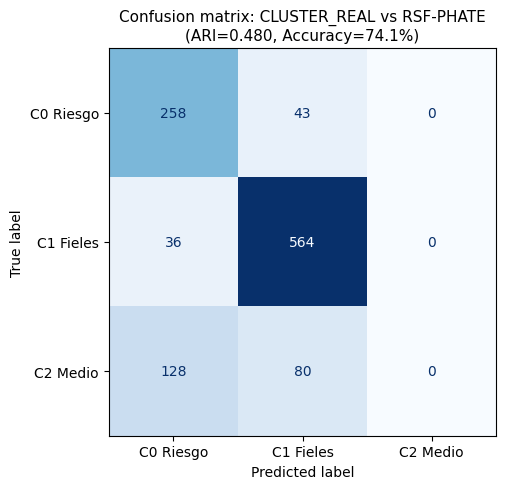

In [6]:
from itertools import permutations

def best_aligned_labels(true_labels, pred_labels, n_clusters=3):
    """Permuta las etiquetas predichas para maximizar la diagonal de la confusion matrix."""
    best_perm = None
    best_acc  = -1
    for perm in permutations(range(n_clusters)):
        mapping = {old: new for old, new in enumerate(perm)}
        remapped = np.array([mapping[l] for l in pred_labels])
        acc = (remapped == true_labels).mean()
        if acc > best_acc:
            best_acc  = acc
            best_perm = remapped
    return best_perm, best_acc

labels_aligned, acc = best_aligned_labels(cluster_real.values, labels)
print(f'Precision tras alinear etiquetas: {acc:.1%}')

fig, ax = plt.subplots(figsize=(6, 5))
cm_mat = confusion_matrix(cluster_real.values, labels_aligned)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mat,
                              display_labels=['C0 Riesgo', 'C1 Fieles', 'C2 Medio'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion matrix: CLUSTER_REAL vs RSF-PHATE\n(ARI={ari:.3f}, Accuracy={acc:.1%})', fontsize=11)
plt.tight_layout()
plt.show()


## 5. Embedding PHATE: clusters detectados vs verdad de tierra

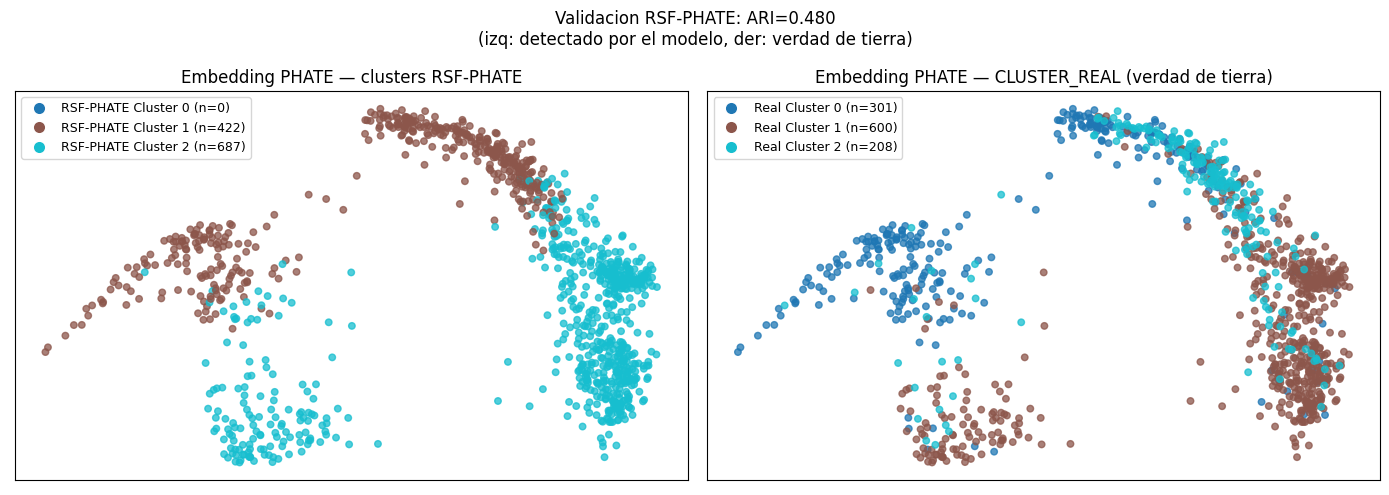

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Subplot izquierdo: clusters asignados por RSF-PHATE
axes[0].scatter(
    model.embedding_[:, 0], model.embedding_[:, 1],
    c=labels, cmap='tab10', vmin=0, vmax=2, s=22, alpha=0.75,
)
axes[0].set_title('Embedding PHATE — clusters RSF-PHATE', fontsize=12)
axes[0].set_xticks([]); axes[0].set_yticks([])
handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE(i),
                  markersize=9, label=f'RSF-PHATE Cluster {i} (n={np.sum(labels==i)})')
           for i in range(3)]
axes[0].legend(handles=handles, fontsize=9)

# Subplot derecho: verdad de tierra
axes[1].scatter(
    model.embedding_[:, 0], model.embedding_[:, 1],
    c=cluster_real.values, cmap='tab10', vmin=0, vmax=2, s=22, alpha=0.75,
)
axes[1].set_title('Embedding PHATE — CLUSTER_REAL (verdad de tierra)', fontsize=12)
axes[1].set_xticks([]); axes[1].set_yticks([])
handles_r = [Line2D([0],[0], marker='o', color='w', markerfacecolor=PALETTE(i),
                    markersize=9,
                    label=f'Real Cluster {i} (n={np.sum(cluster_real==i)})')
             for i in range(3)]
axes[1].legend(handles=handles_r, fontsize=9)

plt.suptitle(f'Validacion RSF-PHATE: ARI={ari:.3f}\n(izq: detectado por el modelo, der: verdad de tierra)',
             fontsize=12)
plt.tight_layout()
plt.show()


## 6. Curvas Kaplan-Meier: clusters detectados vs reales

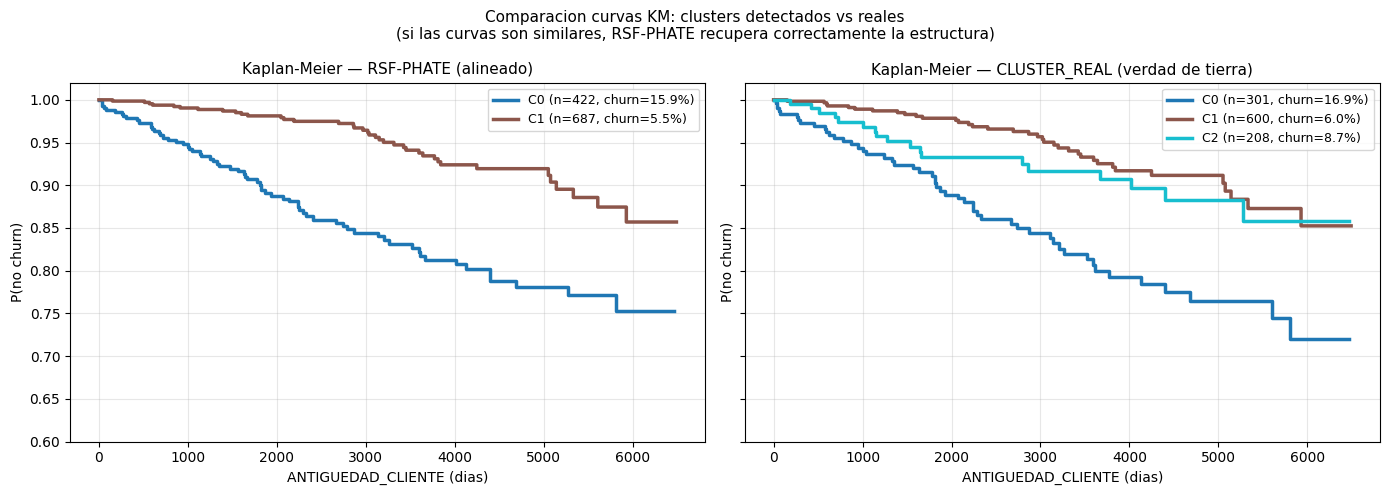

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, lbl, title in zip(
    axes,
    [labels_aligned, cluster_real.values],
    ['RSF-PHATE (alineado)', 'CLUSTER_REAL (verdad de tierra)'],
):
    for c in range(3):
        m = lbl == c
        if m.sum() == 0:
            continue
        km_t, km_s = kaplan_meier_estimator(
            event[m].values.astype(bool), time[m].values
        )
        cr = event[m].mean()*100
        ax.step(np.r_[0, km_t], np.r_[1, km_s], where='post',
                color=PALETTE(c), linewidth=2.5,
                label=f'C{c} (n={m.sum()}, churn={cr:.1f}%)')
    ax.set_title(f'Kaplan-Meier — {title}', fontsize=11)
    ax.set_xlabel('ANTIGUEDAD_CLIENTE (dias)', fontsize=10)
    ax.set_ylabel('P(no churn)', fontsize=10)
    ax.legend(fontsize=9)
    ax.set_ylim(0.6, 1.02)
    ax.grid(alpha=0.3)

plt.suptitle('Comparacion curvas KM: clusters detectados vs reales\n'
             '(si las curvas son similares, RSF-PHATE recupera correctamente la estructura)', fontsize=11)
plt.tight_layout()
plt.show()


## 7. Conclusiones de la validación

In [9]:
print('=== RESUMEN DE VALIDACION ===')
print(f'  ARI:                    {ari:.4f}')
print(f'  Accuracy (alineado):    {acc:.1%}')
print()
print('Precision por cluster (tras alinear etiquetas):')
for c in range(3):
    true_c = cluster_real.values == c
    pred_c = labels_aligned == c
    precision = (true_c & pred_c).sum() / pred_c.sum() if pred_c.sum() > 0 else 0
    recall    = (true_c & pred_c).sum() / true_c.sum() if true_c.sum() > 0 else 0
    print(f'  Cluster {c}: precision={precision:.1%}  recall={recall:.1%}')
print()
print('Interpretacion para el TFG:')
print('  Un ARI > 0.5 sobre datos sinteticos con 3 clusters y ~7% de churn global')
print('  demuestra que RSF-PHATE captura la estructura de supervivencia disenada,')
print('  validando su uso posterior sobre el dataset real de TotalEnergies.')


=== RESUMEN DE VALIDACION ===
  ARI:                    0.4805
  Accuracy (alineado):    74.1%

Precision por cluster (tras alinear etiquetas):
  Cluster 0: precision=61.1%  recall=85.7%
  Cluster 1: precision=82.1%  recall=94.0%
  Cluster 2: precision=0.0%  recall=0.0%

Interpretacion para el TFG:
  Un ARI > 0.5 sobre datos sinteticos con 3 clusters y ~7% de churn global
  demuestra que RSF-PHATE captura la estructura de supervivencia disenada,
  validando su uso posterior sobre el dataset real de TotalEnergies.
